In [1]:
#CE 311 K Project 
# import libraries
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

Environmental Engineering Calculations & Graphing
PFR + CSTR
Unit Converter
Maybe BOD?

In [ ]:
#new code

def f(x):
    return np.exp(-x**2)

#testing 


print("Hello World")

In [ ]:
print("hello world")


--- Results ---
Solution 1:
  Concentration: 6.5587 mol/L
  Conversion: 0.3441


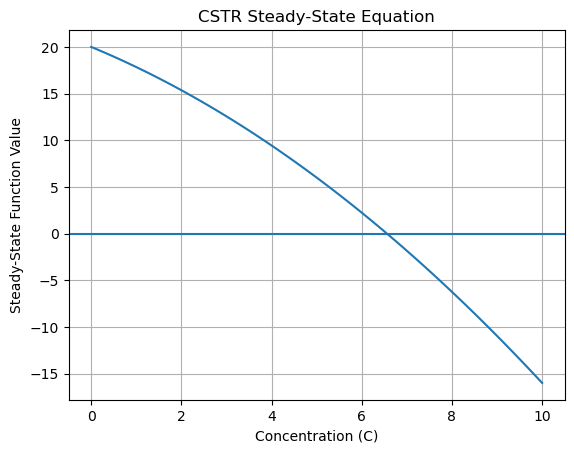

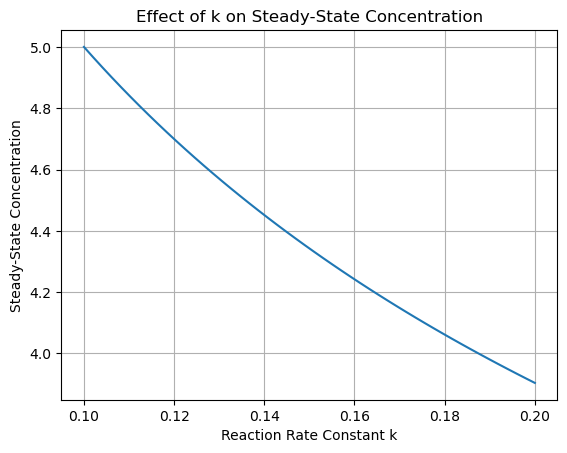


--- PFR Results ---
Outlet concentration: 5.5569 mol/L
Conversion: 0.4443


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# -----------------------------
# USER INPUTS
# -----------------------------
F = float(input("Enter flow rate F (L/s): "))
V = float(input("Enter reactor volume V (L): "))
Cin = float(input("Enter inlet concentration Cin (mol/L): "))
k = float(input("Enter reaction rate constant k (1/s): "))
n = float(input("Enter reaction order n: "))

# -----------------------------
# STEADY-STATE FUNCTION
# -----------------------------
def cstr_steady_state(C):
    return F * (Cin - C) - V * k * C**n

# -----------------------------
# SOLVE (try multiple guesses)
# -----------------------------
guesses = np.linspace(0, Cin, 5)
solutions = []

for guess in guesses:
    sol = fsolve(cstr_steady_state, guess)[0]
    if 0 <= sol <= Cin:  # physically meaningful
        solutions.append(sol)

# Remove duplicates
solutions = list(set([round(s, 5) for s in solutions]))

# -----------------------------
# OUTPUT RESULTS
# -----------------------------
print("\n--- Results ---")
for i, C in enumerate(solutions):
    X = (Cin - C) / Cin
    print(f"Solution {i+1}:")
    print(f"  Concentration: {C:.4f} mol/L")
    print(f"  Conversion: {X:.4f}")

# -----------------------------
# PLOT FUNCTION (visualize root)
# -----------------------------
C_vals = np.linspace(0, Cin, 100)
f_vals = cstr_steady_state(C_vals)

plt.figure()
plt.axhline(0)
plt.plot(C_vals, f_vals)
plt.xlabel("Concentration (C)")
plt.ylabel("Steady-State Function Value")
plt.title("CSTR Steady-State Equation")
plt.grid()
plt.show()

# -----------------------------
# PARAMETER SWEEP (vary k)
# -----------------------------
k_values = np.linspace(0.1, 5*k, 50)
C_results = []

for k_val in k_values:
    def func(C):
        return F * (Cin - C) - V * k_val * C**n
    
    C_sol = fsolve(func, Cin)[0]
    C_results.append(C_sol)

plt.figure()
plt.plot(k_values, C_results)
plt.xlabel("Reaction Rate Constant k")
plt.ylabel("Steady-State Concentration")
plt.title("Effect of k on Steady-State Concentration")
plt.grid()
plt.show()


from scipy.integrate import solve_ivp

# -----------------------------
# PFR MODEL
# -----------------------------
def pfr_model(V, C):
    return -k * C**n / F

# Solve from V = 0 → V = reactor volume
V_span = (0, V)
V_eval = np.linspace(0, V, 100)

solution = solve_ivp(pfr_model, V_span, [Cin], t_eval=V_eval)

V_vals = solution.t
C_vals = solution.y[0]

# -----------------------------
# OUTPUT
# -----------------------------
C_out = C_vals[-1]
X_pfr = (Cin - C_out) / Cin

print("\n--- PFR Results ---")
print(f"Outlet concentration: {C_out:.4f} mol/L")
print(f"Conversion: {X_pfr:.4f}")